# GRIP YOLO Detect Training from Already Split Dataset

Use this notebook when you have already created this split:

```text
yolo_pose_70_20_10/
  images/
    train/
    val/
    test/
  labels/
    train/
    val/
    test/
  data.yaml
```

Your current annotations may be YOLO-pose format with 12 keypoints. For the urgent test, this notebook trains **YOLO Detect**, so it automatically converts each label line to only:

```text
class x_center y_center width height
```

Classes:

```text
0 = left_glove
1 = right_glove
2 = unclear_glove
```

This gives you: train, validation, test, confusion matrix, precision, recall, F1-score, dangerous-error counts, prediction images, ONNX export, and a final results ZIP for GitHub.

In [1]:
# CELL 1 - Install packages and check GPU

!nvidia-smi
!pip install -q -U ultralytics opencv-python pyyaml scikit-learn pandas matplotlib tqdm

from ultralytics import YOLO
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Wed Jul  1 18:49:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 1 - Upload your split ZIP

Zip the **folder itself**:

```text
yolo_pose_70_20_10/
  images/
    train/
    val/
    test/
  labels/
    train/
    val/
    test/
  data.yaml
```

Upload that ZIP in the next cell.

In [2]:
# CELL 2 - Upload and extract your already-split dataset ZIP

from google.colab import files
from pathlib import Path
import zipfile, shutil, os, json, re, yaml

WORKDIR = Path('/content/grip_work')
RAW_EXTRACT = WORKDIR / 'uploaded_split'
shutil.rmtree(WORKDIR, ignore_errors=True)
RAW_EXTRACT.mkdir(parents=True, exist_ok=True)

uploaded = files.upload()
zip_files = [Path(name) for name in uploaded.keys() if name.lower().endswith('.zip')]
if not zip_files:
    raise FileNotFoundError('Upload a .zip file containing yolo_pose_70_20_10 or images/labels/data.yaml')

ZIP_PATH = zip_files[0]
print('Using ZIP:', ZIP_PATH)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(RAW_EXTRACT)

print('Extracted to:', RAW_EXTRACT)
print('Top-level extracted items:')
for p in sorted(RAW_EXTRACT.iterdir()):
    print(' -', p.relative_to(RAW_EXTRACT))

Saving grip_yolo_pose_70_20_10.zip to grip_yolo_pose_70_20_10.zip
Using ZIP: grip_yolo_pose_70_20_10.zip
Extracted to: /content/grip_work/uploaded_split
Top-level extracted items:
 - yolo_pose_70_20_10


In [4]:
# CELL 3 - Find dataset root and inspect structure

from pathlib import Path
from collections import Counter, defaultdict
import os, yaml, json, shutil, random

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# Find a folder containing images/train, images/val, images/test and labels/train, labels/val, labels/test
candidates = []
for p in [RAW_EXTRACT] + [x for x in RAW_EXTRACT.rglob('*') if x.is_dir()]:
    if all((p/'images'/s).exists() for s in ['train','val','test']) and all((p/'labels'/s).exists() for s in ['train','val','test']):
        candidates.append(p)

if not candidates:
    raise FileNotFoundError('Could not find images/train,val,test and labels/train,val,test inside the ZIP.')

SRC_ROOT = candidates[0]
print('Detected dataset root:', SRC_ROOT)

# Load names from YAML if available, otherwise use fixed GRIP names
fixed_names = ['left_glove', 'right_glove', 'unclear_glove']
yaml_path = SRC_ROOT / 'data.yaml'
if yaml_path.exists():
    data = yaml.safe_load(open(yaml_path, 'r')) or {}
    names = data.get('names', fixed_names)
    if isinstance(names, dict):
        names = [names[i] for i in sorted(names)]
    print('Names from data.yaml:', names)
else:
    names = fixed_names
    print('No data.yaml found. Using:', names)

# Force the expected class order for this project
names = fixed_names
print('Final class order used by this notebook:', names)

def count_images(split):
    return len([p for p in (SRC_ROOT/'images'/split).iterdir() if p.suffix.lower() in IMAGE_EXTS])

def count_label_rows(split):
    c = Counter()
    bad = []
    for lab in sorted((SRC_ROOT/'labels'/split).glob('*.txt')):
        for line in lab.read_text().splitlines():
            parts = line.strip().split()
            if not parts:
                continue
            try:
                cls = int(float(parts[0]))
                c[cls] += 1
            except Exception:
                bad.append(str(lab))
    return c, bad

for split in ['train','val','test']:
    c,bad = count_label_rows(split)
    print(f"{split.upper()}")
    print('images:', count_images(split))
    print('objects:', dict(c))
    print('by name:', {names[k]: v for k,v in c.items() if k < len(names)})
    if bad:
        print('Bad label files:', bad[:5])

Detected dataset root: /content/grip_work/uploaded_split/yolo_pose_70_20_10
Names from data.yaml: ['left_glove', 'right_glove', 'unclear_glove']
Final class order used by this notebook: ['left_glove', 'right_glove', 'unclear_glove']
TRAIN
images: 425
objects: {2: 305, 1: 79, 0: 93}
by name: {'unclear_glove': 305, 'right_glove': 79, 'left_glove': 93}
VAL
images: 121
objects: {2: 79, 1: 26, 0: 25}
by name: {'unclear_glove': 79, 'right_glove': 26, 'left_glove': 25}
TEST
images: 62
objects: {2: 51, 0: 8, 1: 10}
by name: {'unclear_glove': 51, 'left_glove': 8, 'right_glove': 10}


## Step 2 - Convert pose labels to detect labels

YOLO-pose labels have many numbers after the bbox. YOLO-detect should only receive the first 5 numbers:

```text
class x_center y_center width height
```

The next cell creates a clean detection dataset in `/content/grip_work/grip_detect_split`.

In [7]:
# CELL 4 - Convert/copy to YOLO Detect dataset

import shutil
from pathlib import Path
from collections import Counter, defaultdict

DETECT_ROOT = WORKDIR / 'grip_detect_split'
shutil.rmtree(DETECT_ROOT, ignore_errors=True)

for split in ['train','val','test']:
    (DETECT_ROOT/'images'/split).mkdir(parents=True, exist_ok=True)
    (DETECT_ROOT/'labels'/split).mkdir(parents=True, exist_ok=True)

converted_counts = {}
label_format_examples = []

for split in ['train','val','test']:
    split_counts = Counter()
    img_dir = SRC_ROOT/'images'/split
    lab_dir = SRC_ROOT/'labels'/split

    for img_path in sorted(img_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        dst_img = DETECT_ROOT/'images'/split/img_path.name
        shutil.copy2(img_path, dst_img)

        lab_path = lab_dir / (img_path.stem + '.txt')
        dst_lab = DETECT_ROOT/'labels'/split/(img_path.stem + '.txt')

        out_lines = []
        if lab_path.exists():
            for line in lab_path.read_text().splitlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    # Keep only class + bbox. This strips keypoints safely.
                    det = parts[:5]
                    try:
                        cls = int(float(det[0]))
                        if cls < 0 or cls >= len(names):
                            continue
                        # Basic numeric validation for bbox values
                        nums = [float(x) for x in det[1:5]]
                        if not all(0 <= x <= 1 for x in nums):
                            continue
                        out_lines.append(f"{cls} {nums[0]:.6f} {nums[1]:.6f} {nums[2]:.6f} {nums[3]:.6f}")
                        split_counts[cls] += 1
                        if len(label_format_examples) < 3:
                            label_format_examples.append({'original_columns': len(parts), 'converted': out_lines[-1]})
                    except Exception:
                        pass
        dst_lab.write_text(''.join(out_lines) + ('' if out_lines else ''))
    converted_counts[split] = split_counts

# Create detect data.yaml
DATA_YAML = DETECT_ROOT / 'data.yaml'
data_yaml = {
    'path': str(DETECT_ROOT),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {i: n for i,n in enumerate(names)}
}
with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print('Detect dataset created:', DETECT_ROOT)
print('data.yaml:', DATA_YAML)
print('Examples of conversion:')
for ex in label_format_examples:
    print(ex)

print('Converted object counts:')
for split, c in converted_counts.items():
    print(split, {names[k]: v for k,v in c.items()})

Detect dataset created: /content/grip_work/grip_detect_split
data.yaml: /content/grip_work/grip_detect_split/data.yaml
Examples of conversion:
{'original_columns': 41, 'converted': '2 0.347297 0.138539 0.510811 0.277077'}
{'original_columns': 41, 'converted': '2 0.297748 0.819057 0.386486 0.360035'}
{'original_columns': 41, 'converted': '2 0.294595 0.683884 0.394595 0.413213'}
Converted object counts:
train {'unclear_glove': 305, 'right_glove': 79, 'left_glove': 93}
val {'unclear_glove': 79, 'right_glove': 26, 'left_glove': 25}
test {'unclear_glove': 51, 'left_glove': 8, 'right_glove': 10}


## Step 3 - Optional train balancing

Your dataset is imbalanced: `unclear_glove` is much higher than left/right. The next cell duplicates only **training** images from minority classes, never validation/test. This is okay for a quick prototype.

For a final paper/project result, clearly say this was used only to reduce training imbalance.

In [8]:
# CELL 5 - Balance training split by duplicating minority-class images

from collections import defaultdict, Counter
import shutil, random

DO_BALANCE_TRAIN = True
random.seed(42)

train_img_dir = DETECT_ROOT/'images'/'train'
train_lab_dir = DETECT_ROOT/'labels'/'train'

# For each training image, decide its main class by the first object in its label.
class_to_items = defaultdict(list)
for lab in sorted(train_lab_dir.glob('*.txt')):
    lines = [ln.strip() for ln in lab.read_text().splitlines() if ln.strip()]
    if not lines:
        continue
    cls = int(float(lines[0].split()[0]))
    # find image
    img = None
    for ext in IMAGE_EXTS:
        cand = train_img_dir / (lab.stem + ext)
        if cand.exists():
            img = cand
            break
    if img:
        class_to_items[cls].append((img, lab))

print('Before balancing images by main class:')
for cls, items in class_to_items.items():
    print(names[cls], len(items))

if DO_BALANCE_TRAIN and class_to_items:
    max_count = max(len(v) for v in class_to_items.values())
    dup_count = 0
    for cls, items in class_to_items.items():
        need = max_count - len(items)
        if need <= 0:
            continue
        for i in range(need):
            img, lab = random.choice(items)
            new_stem = f"{img.stem}_bal_c{cls}_{i:04d}"
            new_img = train_img_dir / f"{new_stem}{img.suffix}"
            new_lab = train_lab_dir / f"{new_stem}.txt"
            shutil.copy2(img, new_img)
            shutil.copy2(lab, new_lab)
            dup_count += 1
    print('Duplicated training images:', dup_count)

# Recount after balancing
after = Counter()
for lab in sorted(train_lab_dir.glob('*.txt')):
    lines = [ln.strip() for ln in lab.read_text().splitlines() if ln.strip()]
    if lines:
        after[int(float(lines[0].split()[0]))] += 1
print('After balancing images by main class:', {names[k]: v for k,v in after.items()})
print('Final train image count:', len([p for p in train_img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]))

Before balancing images by main class:
unclear_glove 275
right_glove 75
left_glove 75
Duplicated training images: 400
After balancing images by main class: {'unclear_glove': 275, 'right_glove': 275, 'left_glove': 275}
Final train image count: 825


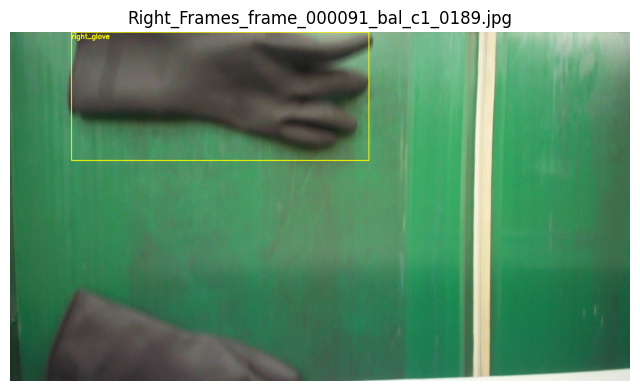

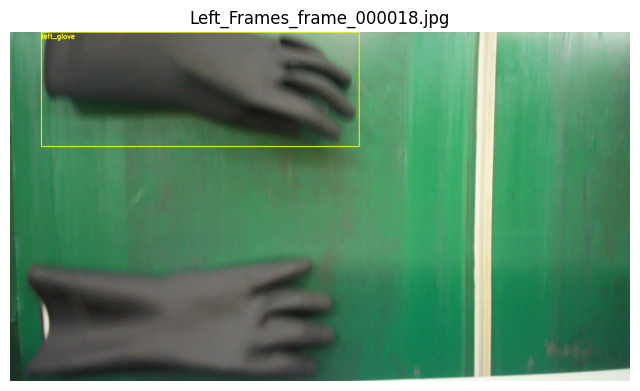

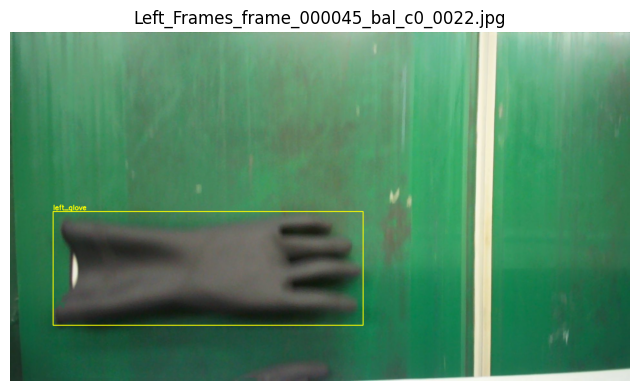

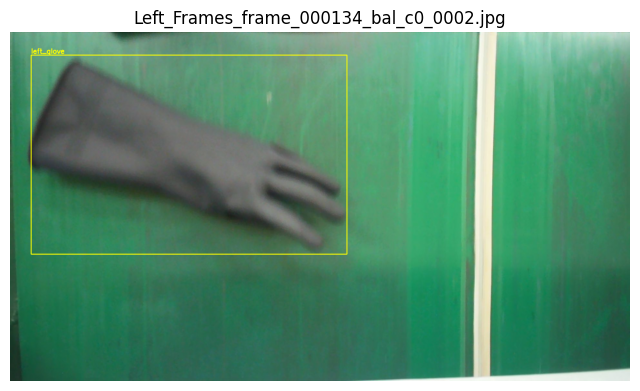

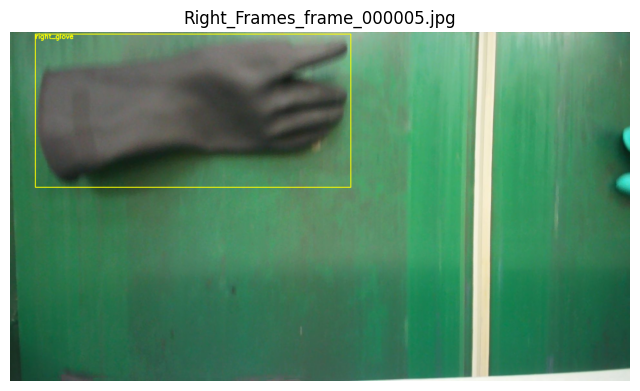

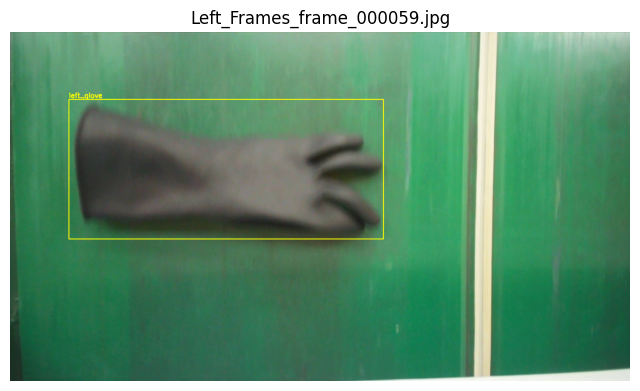

In [9]:
# CELL 6 - Visual check: draw labels on random training images

import cv2, random, matplotlib.pyplot as plt
from pathlib import Path

sample_imgs = random.sample([p for p in (DETECT_ROOT/'images/train').iterdir() if p.suffix.lower() in IMAGE_EXTS], k=min(6, len(list((DETECT_ROOT/'images/train').iterdir()))))

for img_path in sample_imgs:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    h,w = img.shape[:2]
    lab_path = DETECT_ROOT/'labels/train'/(img_path.stem + '.txt')
    if lab_path.exists():
        for line in lab_path.read_text().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            cls, xc, yc, bw, bh = int(float(parts[0])), *map(float, parts[1:5])
            x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,255), 2)
            cv2.putText(img, names[cls], (x1, max(20,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,255), 2)
    plt.figure(figsize=(8,5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(img_path.name)
    plt.axis('off')
    plt.show()

## Step 4 - Train YOLO Detect

Ultralytics automatically saves:

```text
best.pt  -> best validation model
last.pt  -> latest epoch model
results.csv -> epoch metrics/losses
confusion_matrix.png -> validation confusion matrix
```

`best.pt` is saved when validation fitness improves. If a later epoch is worse, it keeps the old best and continues.

In [10]:
# CELL 7 - Train model

from ultralytics import YOLO
from pathlib import Path

MODEL_NAME = 'yolo11n.pt'   # If this fails, change to 'yolov8n.pt'
PROJECT_DIR = '/content/grip_runs'
RUN_NAME = 'grip_lr_unclear_detect_v1'

model = YOLO(MODEL_NAME)

results = model.train(
    data=str(DATA_YAML),
    task='detect',
    imgsz=640,
    epochs=100,
    batch=16,
    patience=20,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    cos_lr=True,
    warmup_epochs=3,
    hsv_h=0.015,
    hsv_s=0.50,
    hsv_v=0.40,
    degrees=25,
    translate=0.10,
    scale=0.25,
    shear=0.0,
    perspective=0.0005,
    fliplr=0.0,   # IMPORTANT: do not flip left/right gloves
    flipud=0.0,
    mosaic=0.30,
    mixup=0.0,
    close_mosaic=10,
    plots=True,
    save=True,
    project=PROJECT_DIR,
    name=RUN_NAME,
    exist_ok=True,
    seed=42
)

RUN_DIR = Path(PROJECT_DIR) / RUN_NAME
BEST_PT = RUN_DIR / 'weights' / 'best.pt'
LAST_PT = RUN_DIR / 'weights' / 'last.pt'
print('Run dir:', RUN_DIR)
print('Best model:', BEST_PT, BEST_PT.exists())
print('Last model:', LAST_PT, LAST_PT.exists())

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/grip_work/grip_detect_split/data.yaml, degrees=25, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=grip_lr_unclear_detect_v1, nbs=64, nms=False, opset=None, optimize=False, optimiz

In [12]:
# CELL 8 - Validate on validation set and test set

from ultralytics import YOLO

best_model = YOLO(str(BEST_PT))

print('VALIDATION METRICS')
val_metrics = best_model.val(data=str(DATA_YAML), split='val', imgsz=640, conf=0.25, iou=0.5, plots=True, project=PROJECT_DIR, name=RUN_NAME + '_val_eval', exist_ok=True)
print(val_metrics)

print('TEST METRICS')
test_metrics = best_model.val(data=str(DATA_YAML), split='test', imgsz=640, conf=0.25, iou=0.5, plots=True, project=PROJECT_DIR, name=RUN_NAME + '_test_eval', exist_ok=True)
print(test_metrics)

VALIDATION METRICS
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2064.5±1309.3 MB/s, size: 103.5 KB)
val: Scanning /content/grip_work/grip_detect_split/labels/val.cache... 121 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 121/121 33.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 9, len(boxes) = 121. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.1it/s 7.2s
                   all        121        121      0.906      0.876      0.859      0.755
            left_glove         23         23      0.833      0.869      0.802      0.713
      

## Step 5 - Manual object-level confusion matrix and F1 score

This cell matches predicted boxes to ground-truth boxes using IoU. It also counts:

- missed objects
- false detections
- dangerous error: `right_glove -> left_glove`
- unsafe unclear false accepts: `unclear_glove -> left/right`

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/manual_test_predictions.csv
Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/manual_test_confusion_matrix.csv


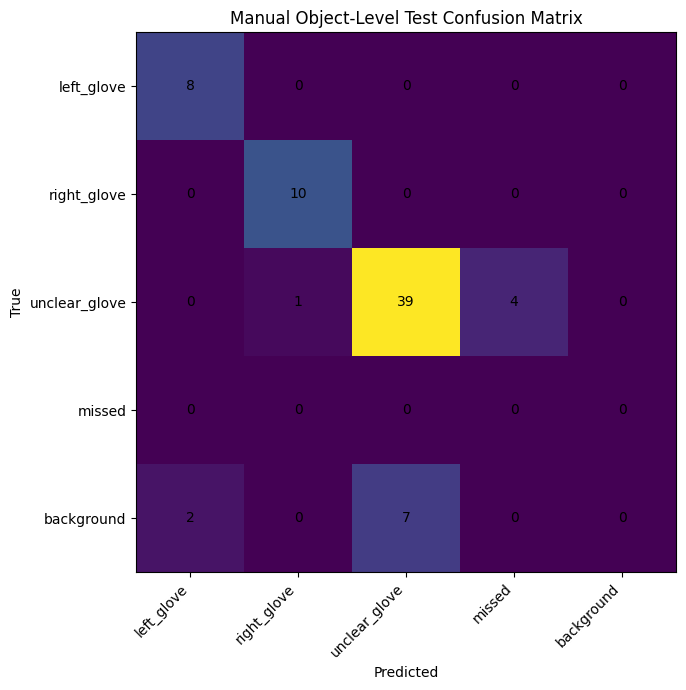

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/manual_test_confusion_matrix.png
Classification report for real classes:
               precision    recall  f1-score   support

   left_glove       0.80      1.00      0.89         8
  right_glove       0.91      1.00      0.95        10
unclear_glove       0.85      0.89      0.87        44

    micro avg       0.85      0.92      0.88        62
    macro avg       0.85      0.96      0.90        62
 weighted avg       0.85      0.92      0.88        62

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/manual_test_classification_report.csv
IMPORTANT INDUSTRIAL ERRORS
DANGEROUS: true right_glove predicted as left_glove = 0
False reject: true left_glove predicted as right_glove = 0
Unsafe unclear accepted as left_glove = 0
Unsafe unclear accepted as right_glove = 1
Missed right_glove detections = 0


In [15]:
# CELL 9 - Manual test confusion matrix, F1, precision, recall, dangerous errors

import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score, accuracy_score

CONF_THRES = 0.25
IOU_MATCH_THRES = 0.50
TEST_IMG_DIR = DETECT_ROOT / 'images' / 'test'
TEST_LAB_DIR = DETECT_ROOT / 'labels' / 'test'
REPORT_DIR = RUN_DIR / 'manual_test_report'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

all_labels_for_matrix = names + ['missed', 'background']

def yolo_to_xyxy(row, w, h):
    cls, xc, yc, bw, bh = row
    x1 = (xc - bw/2) * w
    y1 = (yc - bh/2) * h
    x2 = (xc + bw/2) * w
    y2 = (yc + bh/2) * h
    return [x1,y1,x2,y2]

def box_iou(a,b):
    ax1,ay1,ax2,ay2 = a
    bx1,by1,bx2,by2 = b
    ix1,iy1 = max(ax1,bx1), max(ay1,by1)
    ix2,iy2 = min(ax2,bx2), min(ay2,by2)
    iw,ih = max(0, ix2-ix1), max(0, iy2-iy1)
    inter = iw*ih
    area_a = max(0, ax2-ax1) * max(0, ay2-ay1)
    area_b = max(0, bx2-bx1) * max(0, by2-by1)
    union = area_a + area_b - inter + 1e-9
    return inter/union

rows = []
y_true = []
y_pred = []

for img_path in sorted([p for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS]):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    h,w = img.shape[:2]

    # Ground truth
    gt = []
    lab_path = TEST_LAB_DIR / (img_path.stem + '.txt')
    if lab_path.exists():
        for line in lab_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                cls = int(float(parts[0]))
                vals = [float(x) for x in parts[1:5]]
                gt.append({'cls': cls, 'box': yolo_to_xyxy([cls] + vals, w, h)})

    # Predictions
    pred_res = best_model.predict(source=str(img_path), imgsz=640, conf=CONF_THRES, iou=0.5, verbose=False)[0]
    preds = []
    if pred_res.boxes is not None:
        for b in pred_res.boxes:
            cls = int(b.cls[0])
            conf = float(b.conf[0])
            box = [float(x) for x in b.xyxy[0].cpu().numpy().tolist()]
            preds.append({'cls': cls, 'conf': conf, 'box': box})

    # Greedy matching by IoU
    pairs = []
    for gi, g in enumerate(gt):
        for pi, p in enumerate(preds):
            pairs.append((box_iou(g['box'], p['box']), gi, pi))
    pairs.sort(reverse=True, key=lambda x: x[0])

    matched_g = set(); matched_p = set()
    for iou, gi, pi in pairs:
        if iou < IOU_MATCH_THRES:
            break
        if gi in matched_g or pi in matched_p:
            continue
        matched_g.add(gi); matched_p.add(pi)
        t = names[gt[gi]['cls']]
        pr = names[preds[pi]['cls']]
        y_true.append(t); y_pred.append(pr)
        rows.append({'image': img_path.name, 'true': t, 'pred': pr, 'conf': preds[pi]['conf'], 'iou': iou, 'case': 'matched'})

    # Missed GT objects
    for gi, g in enumerate(gt):
        if gi not in matched_g:
            t = names[g['cls']]
            y_true.append(t); y_pred.append('missed')
            rows.append({'image': img_path.name, 'true': t, 'pred': 'missed', 'conf': None, 'iou': None, 'case': 'missed_gt'})

    # False detections
    for pi, p in enumerate(preds):
        if pi not in matched_p:
            pr = names[p['cls']]
            y_true.append('background'); y_pred.append(pr)
            rows.append({'image': img_path.name, 'true': 'background', 'pred': pr, 'conf': p['conf'], 'iou': None, 'case': 'false_detection'})

pred_df = pd.DataFrame(rows)
pred_csv = REPORT_DIR / 'manual_test_predictions.csv'
pred_df.to_csv(pred_csv, index=False)
print('Saved:', pred_csv)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=all_labels_for_matrix)
cm_df = pd.DataFrame(cm, index=[f'TRUE_{x}' for x in all_labels_for_matrix], columns=[f'PRED_{x}' for x in all_labels_for_matrix])
cm_csv = REPORT_DIR / 'manual_test_confusion_matrix.csv'
cm_df.to_csv(cm_csv)
print('Saved:', cm_csv)

plt.figure(figsize=(9,7))
plt.imshow(cm, interpolation='nearest')
plt.title('Manual Object-Level Test Confusion Matrix')
plt.xticks(range(len(all_labels_for_matrix)), all_labels_for_matrix, rotation=45, ha='right')
plt.yticks(range(len(all_labels_for_matrix)), all_labels_for_matrix)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
cm_png = REPORT_DIR / 'manual_test_confusion_matrix.png'
plt.savefig(cm_png, dpi=200)
plt.show()
print('Saved:', cm_png)

# Classification report for the three real classes; missed/background still affect precision/recall as other labels.
print('Classification report for real classes:')
print(classification_report(y_true, y_pred, labels=names, zero_division=0))

report_dict = classification_report(y_true, y_pred, labels=names, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report_dict).T
report_csv = REPORT_DIR / 'manual_test_classification_report.csv'
report_df.to_csv(report_csv)
print('Saved:', report_csv)

# Critical error counts
right_as_left = int(((pred_df['true'] == 'right_glove') & (pred_df['pred'] == 'left_glove')).sum())
left_as_right = int(((pred_df['true'] == 'left_glove') & (pred_df['pred'] == 'right_glove')).sum())
unclear_as_left = int(((pred_df['true'] == 'unclear_glove') & (pred_df['pred'] == 'left_glove')).sum())
unclear_as_right = int(((pred_df['true'] == 'unclear_glove') & (pred_df['pred'] == 'right_glove')).sum())
missed_right = int(((pred_df['true'] == 'right_glove') & (pred_df['pred'] == 'missed')).sum())

print('IMPORTANT INDUSTRIAL ERRORS')
print('DANGEROUS: true right_glove predicted as left_glove =', right_as_left)
print('False reject: true left_glove predicted as right_glove =', left_as_right)
print('Unsafe unclear accepted as left_glove =', unclear_as_left)
print('Unsafe unclear accepted as right_glove =', unclear_as_right)
print('Missed right_glove detections =', missed_right)

results.csv exists: True /content/grip_runs/grip_lr_unclear_detect_v1/results.csv


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,1939.22,0.35242,0.22297,0.88650,0.89922,0.87776,0.91574,0.78802,0.59508,0.47526,0.91484,0.000016,0.000016,0.000016
96,97,1959.32,0.34627,0.22283,0.89833,0.89711,0.87999,0.91574,0.78950,0.59598,0.46848,0.91478,0.000014,0.000014,0.000014
97,98,1977.91,0.36652,0.22807,0.88496,0.89998,0.87999,0.91342,0.78074,0.59794,0.46652,0.91541,0.000012,0.000012,0.000012
98,99,1998.02,0.34606,0.22120,0.89181,0.90011,0.87999,0.90985,0.78213,0.59428,0.46784,0.91539,0.000011,0.000011,0.000011
99,100,2016.86,0.36018,0.22186,0.88791,0.89803,0.87999,0.91455,0.79124,0.59615,0.46650,0.91521,0.000010,0.000010,0.000010


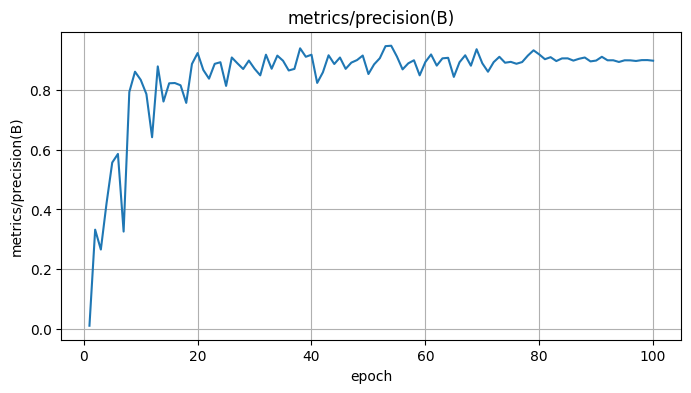

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/metrics_precision(B).png


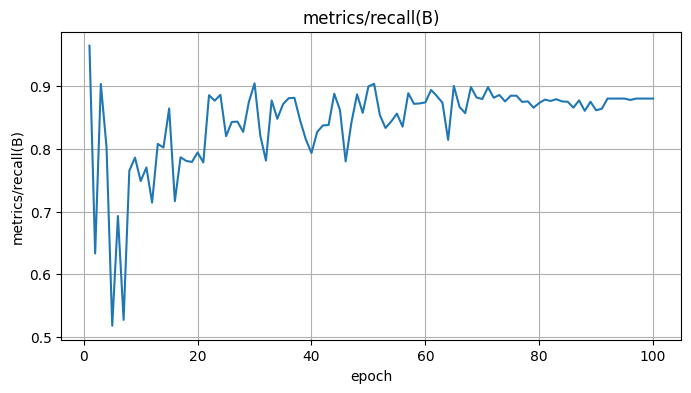

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/metrics_recall(B).png


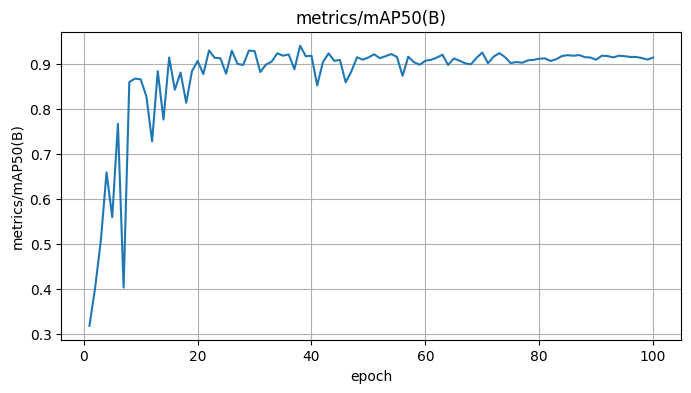

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/metrics_mAP50(B).png


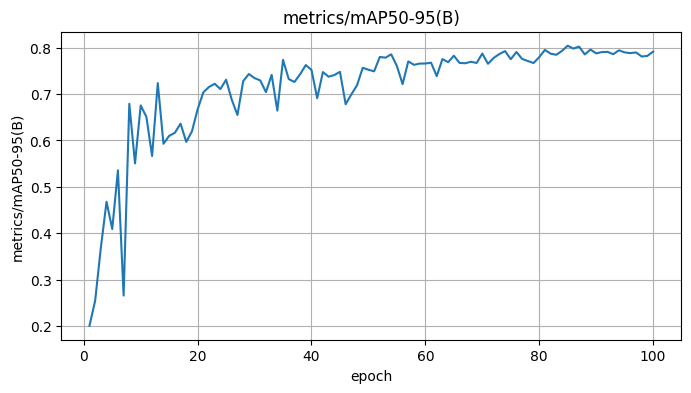

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/metrics_mAP50-95(B).png


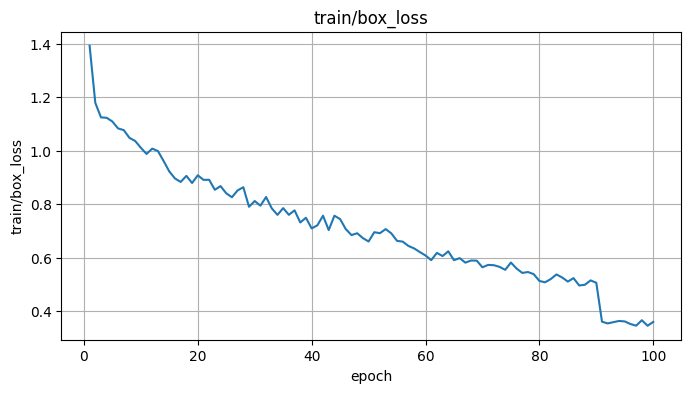

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/train_box_loss.png


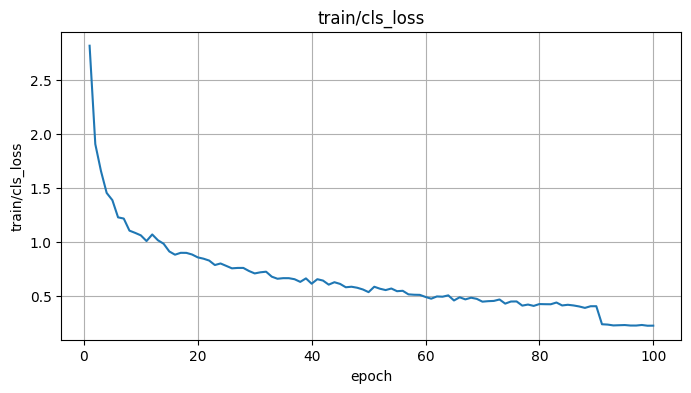

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/train_cls_loss.png


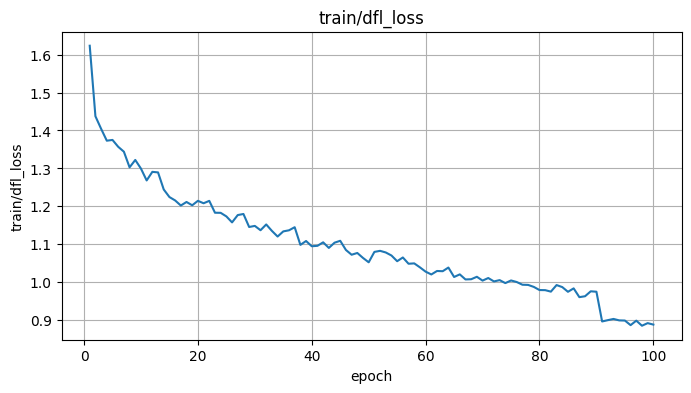

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/train_dfl_loss.png


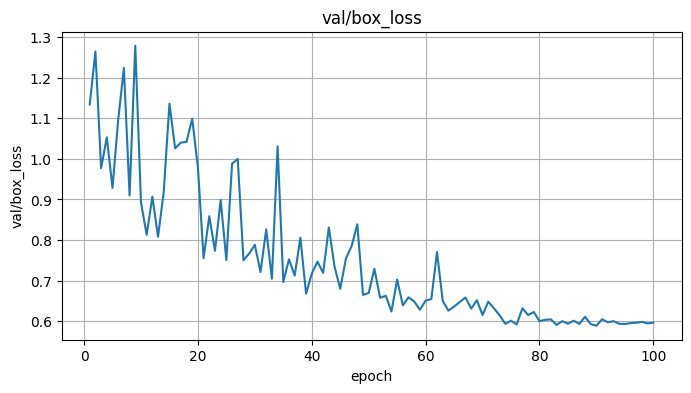

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/val_box_loss.png


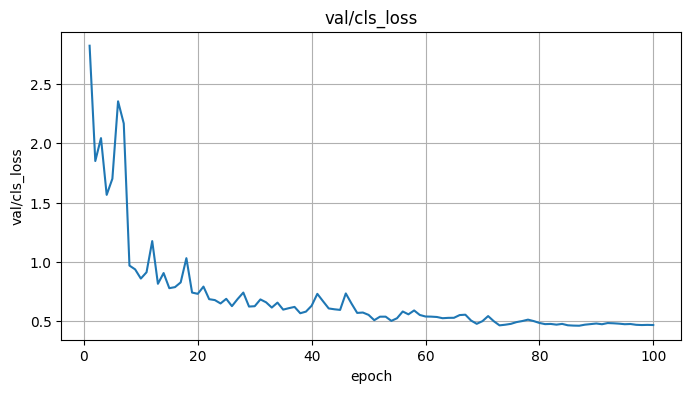

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/val_cls_loss.png


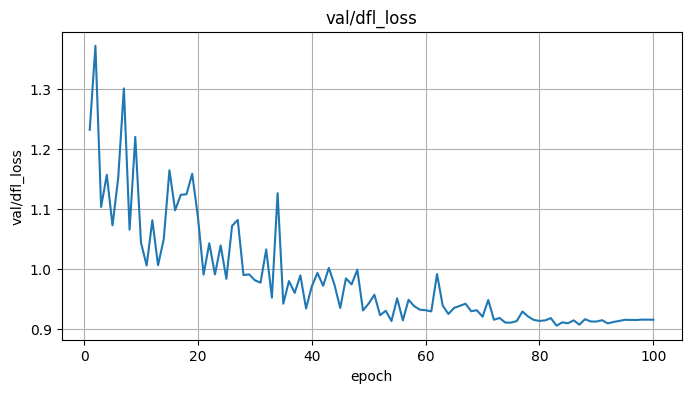

Saved: /content/grip_runs/grip_lr_unclear_detect_v1/manual_test_report/val_dfl_loss.png


In [16]:
# CELL 10 - Plot training curves from results.csv

import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

results_csv = RUN_DIR / 'results.csv'
print('results.csv exists:', results_csv.exists(), results_csv)

df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]
display(df.tail())

# Plot useful metrics if present
metric_cols = [c for c in df.columns if any(k in c for k in ['metrics/mAP50', 'metrics/precision', 'metrics/recall'])]
for col in metric_cols:
    plt.figure(figsize=(8,4))
    plt.plot(df['epoch'], df[col])
    plt.title(col)
    plt.xlabel('epoch')
    plt.ylabel(col)
    plt.grid(True)
    out = REPORT_DIR / (col.replace('/', '_') + '.png')
    plt.savefig(out, dpi=160)
    plt.show()
    print('Saved:', out)

loss_cols = [c for c in df.columns if 'loss' in c]
for col in loss_cols:
    plt.figure(figsize=(8,4))
    plt.plot(df['epoch'], df[col])
    plt.title(col)
    plt.xlabel('epoch')
    plt.ylabel(col)
    plt.grid(True)
    out = REPORT_DIR / (col.replace('/', '_') + '.png')
    plt.savefig(out, dpi=160)
    plt.show()
    print('Saved:', out)

In [17]:
# CELL 11 - Save sample predictions on test images

PRED_DIR = RUN_DIR / 'test_prediction_images'
_ = best_model.predict(source=str(TEST_IMG_DIR), imgsz=640, conf=0.25, iou=0.5, save=True, project=str(RUN_DIR), name='test_prediction_images', exist_ok=True)
print('Prediction images saved in:', PRED_DIR)

Results saved to /content/grip_runs/grip_lr_unclear_detect_v1/test_prediction_images
Prediction images saved in: /content/grip_runs/grip_lr_unclear_detect_v1/test_prediction_images


In [18]:
# CELL 12 - Export best model to ONNX

export_path = best_model.export(format='onnx', imgsz=640, simplify=True)
print('ONNX exported to:', export_path)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/grip_runs/grip_lr_unclear_detect_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 305ms
Prepared 4 packages in 2.00s
Installed 4 packages in 278ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 6.0s, saved as '/con

In [19]:
# CELL 13 - Package results into one ZIP for download/GitHub

import shutil
from pathlib import Path

PACKAGE_DIR = WORKDIR / 'github_results_package'
shutil.rmtree(PACKAGE_DIR, ignore_errors=True)
PACKAGE_DIR.mkdir(parents=True, exist_ok=True)

# Copy key outputs
copy_items = [
    BEST_PT,
    LAST_PT,
    RUN_DIR / 'results.csv',
    RUN_DIR / 'args.yaml',
    REPORT_DIR / 'manual_test_predictions.csv',
    REPORT_DIR / 'manual_test_confusion_matrix.csv',
    REPORT_DIR / 'manual_test_confusion_matrix.png',
    REPORT_DIR / 'manual_test_classification_report.csv',
    DATA_YAML,
]
for item in copy_items:
    if Path(item).exists():
        shutil.copy2(item, PACKAGE_DIR / Path(item).name)

# Copy Ultralytics plots if present
for pattern in ['confusion_matrix*.png', 'results.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png', 'F1_curve.png', 'labels.jpg', 'val_batch*.jpg']:
    for p in RUN_DIR.glob(pattern):
        if p.exists():
            shutil.copy2(p, PACKAGE_DIR / p.name)

# Copy manual plots
for p in REPORT_DIR.glob('*.png'):
    shutil.copy2(p, PACKAGE_DIR / p.name)

# Copy ONNX if it exists next to weights
for p in (RUN_DIR/'weights').glob('*.onnx'):
    shutil.copy2(p, PACKAGE_DIR / p.name)

# README summary
readme = f"""# GRIP Left/Right/Unclear YOLO Detect Prototype Results

Classes:
- 0 = left_glove
- 1 = right_glove
- 2 = unclear_glove

Dataset split used:
- Train images: {len([p for p in (DETECT_ROOT/'images/train').iterdir() if p.suffix.lower() in IMAGE_EXTS])}
- Val images: {len([p for p in (DETECT_ROOT/'images/val').iterdir() if p.suffix.lower() in IMAGE_EXTS])}
- Test images: {len([p for p in (DETECT_ROOT/'images/test').iterdir() if p.suffix.lower() in IMAGE_EXTS])}

Training:
- Model: {MODEL_NAME}
- Task: YOLO detect
- Image size: 640
- Epochs max: 100
- Early stopping patience: 20
- Horizontal flip disabled because it changes glove handedness.

Important result files:
- best.pt: best validation model
- last.pt: final epoch model
- results.csv: epoch metrics and losses
- manual_test_predictions.csv: object-level predictions
- manual_test_confusion_matrix.png: object-level test confusion matrix
- manual_test_classification_report.csv: precision, recall, F1

Industrial safety note:
The most important error is true right_glove predicted as left_glove, because that means a wrong-hand glove may pass.
"""
(PACKAGE_DIR / 'README.md').write_text(readme)

zip_base = '/content/GRIP_YOLO_detect_results_package'
zip_path = shutil.make_archive(zip_base, 'zip', PACKAGE_DIR)
print('Created package:', zip_path)

from google.colab import files
files.download(zip_path)

Created package: /content/GRIP_YOLO_detect_results_package.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 6 - What to upload to GitHub

Upload the downloaded results ZIP contents into your repository, for example:

```text
runs/grip_lr_unclear_detect_v1/
  best.pt
  last.pt
  results.csv
  manual_test_predictions.csv
  manual_test_confusion_matrix.png
  manual_test_classification_report.csv
  README.md
```

Recommended commit message:

```bash
git add runs/grip_lr_unclear_detect_v1
git commit -m "Train GRIP left-right-unclear YOLO detect prototype"
git push
```